# Sequential Chain




## Install dependencies
Run this once in a fresh environment.


In [1]:
# %pip -q install langgraph langchain-openai python-dotenv

## 1) Imports

In [2]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

## 2) Load environment variables - please read instructions carefully

In [3]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [4]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Define Node

In [5]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.4
)

# llm = ChatOpenAI(
#     model="gpt-4.1-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.4
# )

class ResearchState(TypedDict):
    topic: str
    research_facts: str
    summary: str
    tweet: str
    status: str
    error: str



def research_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Research this topic thoroughly and extract 5 bullet-point facts:\n\n{state['topic']}"
        )
        return {"research_facts": response.content}
    except Exception as e:
        return {
            "research_facts": "",
            "status": "error",
            "error": f"Research failed: {str(e)}"
        }


def summarise_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Identify the single most surprising finding of this research:\n\n{state['research_facts']}"
        )
        return {"summary": response.content}
    except Exception as e:
        return {
            "summary": "",
            "status": "error",
            "error": f"Summarization failed: {str(e)}"
        }


def tweet_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Create a two-sentence tweet summarizing the finding:\n\n{state['summary']}"
        )
        return {"tweet": response.content}
    except Exception as e:
        return {
            "tweet": "",
            "status": "error",
            "error": f"Format failed: {str(e)}"
        }

## 4) Build the sequential chain

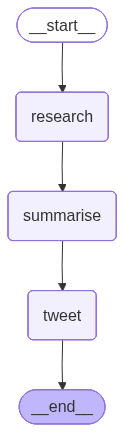

In [6]:
builder = StateGraph(ResearchState)

builder.add_node("research", research_node)
builder.add_node("summarise", summarise_node)
builder.add_node("tweet", tweet_node)

builder.add_edge(START, "research")
builder.add_edge("research", "summarise")
builder.add_edge("summarise", "tweet")
builder.add_edge("tweet", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [10]:
result = graph.invoke({
    "topic": "The impact of AI on the job market"
})

print(result["research_facts"])

print("-------------------------------")

print(result["summary"])

print("-------------------------------")

print(result["tweet"])

if result.get("status") == "error":
    print("Error:", result.get("error"))

- **Job Automation and Displacement:** AI technologies are automating routine and repetitive tasks across various industries, leading to displacement of certain job roles, particularly in manufacturing, customer service, and data entry.

- **Creation of New Job Categories:** AI is generating new employment opportunities in fields such as AI development, data science, machine learning engineering, and AI ethics, requiring specialized skills and education.

- **Shift in Skill Requirements:** There is an increasing demand for workers with advanced digital skills, critical thinking, creativity, and emotional intelligence, as AI handles more technical and repetitive tasks.

- **Enhanced Productivity and Efficiency:** AI tools augment human capabilities, enabling workers to perform tasks faster and with greater accuracy, which can lead to economic growth and the creation of higher-value jobs.

- **Potential for Increased Inequality:** The benefits of AI adoption may be unevenly distributed, 